In [ ]:
!nvidia-smi

In [ ]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor

model_name = "Qwen/Qwen2.5-VL-3B-Instruct"

print("Loading Qwen2.5-VL 3B...")

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)

processor = AutoProcessor.from_pretrained(model_name)

print("Qwen2.5-VL 3B loaded successfully!")

In [ ]:
from PIL import Image
from IPython.display import display

image_path = list(uploaded.keys())[0]

image = Image.open(image_path)
display(image)

print("Image:", image_path)

In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
from PIL import Image
from IPython.display import display

image_path = list(uploaded.keys())[0]

image = Image.open(image_path)
display(image)

print("Image:", image_path)

In [ ]:
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image_path,
            },
            {
                "type": "text",
                "text": "What type of disaster is visible in this image? Describe what you can see."
            },
        ],
    }
]

text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

image_inputs, video_inputs = process_vision_info(messages)

inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt"
)

inputs = inputs.to("cuda")

generated_ids = model.generate(
    **inputs,
    max_new_tokens=100
)

generated_ids_trimmed = [
    out_ids[len(in_ids):]
    for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]

output_text = processor.batch_decode(
    generated_ids_trimmed,
    skip_special_tokens=True
)

print("Qwen's answer:")
print(output_text[0])

In [ ]:
from qwen_vl_utils import process_vision_info

In [ ]:
!pip install -q qwen-vl-utils

In [ ]:
from qwen_vl_utils import process_vision_info

print("Qwen vision utility is ready!")

In [ ]:
from PIL import Image
from IPython.display import display

image_path = list(uploaded.keys())[0]

image = Image.open(image_path)
display(image)

print("Image:", image_path)

In [ ]:
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image_path,
            },
            {
                "type": "text",
                "text": "What type of disaster is visible in this image? Describe what you can see."
            },
        ],
    }
]

text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

image_inputs, video_inputs = process_vision_info(messages)

inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt"
)

inputs = inputs.to("cuda")

generated_ids = model.generate(
    **inputs,
    max_new_tokens=100
)

generated_ids_trimmed = [
    out_ids[len(in_ids):]
    for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]

output_text = processor.batch_decode(
    generated_ids_trimmed,
    skip_special_tokens=True
)

print("Qwen's answer:")
print(output_text[0])

In [ ]:
del model
del processor

import torch
torch.cuda.empty_cache()

print("GPU memory cleared")

In [ ]:
!pip install -q bitsandbytes

In [ ]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor

model_name = "Qwen/Qwen2.5-VL-3B-Instruct"

print("Loading 3B model in 4-bit...")

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_name,
    device_map="auto",
    load_in_4bit=True,
    torch_dtype="auto"
)

processor = AutoProcessor.from_pretrained(model_name)

print("3B 4-bit model loaded successfully!")

In [ ]:
from transformers import BitsAndBytesConfig

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype="float16",
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True
)

print("4-bit configuration ready!")

In [ ]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor

model_name = "Qwen/Qwen2.5-VL-3B-Instruct"

print("Loading Qwen 3B in 4-bit...")

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_name,
    quantization_config=quantization_config,
    device_map="auto"
)

processor = AutoProcessor.from_pretrained(model_name)

print("Qwen 3B 4-bit loaded successfully!")

In [ ]:
!pip install -q -U "bitsandbytes>=0.46.1"

In [ ]:
!pip install -q -U transformers accelerate qwen-vl-utils

In [ ]:
!pip install -q -U "bitsandbytes>=0.46.1"

In [ ]:
import torch
import bitsandbytes as bnb

print("GPU:", torch.cuda.get_device_name(0))
print("bitsandbytes:", bnb.__version__)

In [ ]:
from transformers import (
    Qwen2_5_VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig
)

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True
)

model_name = "Qwen/Qwen2.5-VL-3B-Instruct"

print("Loading Qwen 3B in 4-bit...")

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_name,
    quantization_config=quantization_config,
    device_map="auto"
)

processor = AutoProcessor.from_pretrained(model_name)

print("Qwen 3B 4-bit loaded successfully!")

In [ ]:
import torch

from transformers import (
    Qwen2_5_VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig
)

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True
)

model_name = "Qwen/Qwen2.5-VL-3B-Instruct"

print("Loading Qwen 3B in 4-bit...")

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_name,
    quantization_config=quantization_config,
    device_map="auto"
)

processor = AutoProcessor.from_pretrained(model_name)

print("Qwen 3B 4-bit loaded successfully!")

In [ ]:
!pip install -U --force-reinstall "bitsandbytes>=0.46.1"

In [ ]:
import bitsandbytes as bnb

print("bitsandbytes version:", bnb.__version__)

In [ ]:
import bitsandbytes as bnb
print("bitsandbytes version:", bnb.__version__)

In [ ]:
import torch

print("GPU:", torch.cuda.get_device_name(0))
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)

In [ ]:
from transformers import (
    Qwen2_5_VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig
)

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

model_name = "Qwen/Qwen2.5-VL-3B-Instruct"

print("Loading Qwen 3B...")

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_name,
    quantization_config=quantization_config,
    device_map="auto"
)

processor = AutoProcessor.from_pretrained(model_name)

print("✅ Qwen 3B loaded successfully!")

In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
from PIL import Image
from IPython.display import display

image_path = list(uploaded.keys())[0]

image = Image.open(image_path)
display(image)

print("Image:", image_path)

In [ ]:
from qwen_vl_utils import process_vision_info

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image_path
            },
            {
                "type": "text",
                "text": "What type of disaster is shown in this image?"
            }
        ]
    }
]

text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

image_inputs, video_inputs = process_vision_info(messages)

inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt"
)

inputs = inputs.to("cuda")

generated_ids = model.generate(
    **inputs,
    max_new_tokens=50
)

generated_ids_trimmed = [
    out_ids[len(in_ids):]
    for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]

answer = processor.batch_decode(
    generated_ids_trimmed,
    skip_special_tokens=True
)

print("VLM Answer:", answer[0])

In [ ]:
!pip install -q -U transformers accelerate pillow

In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

In [ ]:
import torch
from transformers import AutoProcessor, AutoModelForVision2Seq

model_id = "HuggingFaceTB/SmolVLM-500M-Instruct"

print("Loading SmolVLM...")

processor = AutoProcessor.from_pretrained(model_id)

model = AutoModelForVision2Seq.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("SmolVLM loaded successfully!")

In [ ]:
!pip install -q --force-reinstall --no-cache-dir pillow

In [ ]:
from PIL import Image

print("Pillow is working!")
print("Pillow version:", Image.__version__)

In [ ]:
from transformers import AutoProcessor, AutoModelForVision2Seq

print("Transformers import is working!")

In [ ]:
import transformers

print("Transformers version:", transformers.__version__)

In [ ]:
from transformers import AutoProcessor, AutoModelForImageTextToText

print("Imports successful!")

In [ ]:
import torch

model_id = "HuggingFaceTB/SmolVLM-500M-Instruct"

print("Loading SmolVLM...")

processor = AutoProcessor.from_pretrained(model_id)

model = AutoModelForImageTextToText.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("SmolVLM loaded successfully!")

In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
from PIL import Image

image_path = list(uploaded.keys())[0]
image = Image.open(image_path).convert("RGB")

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": "What type of disaster is shown in this image?"}
        ]
    }
]

prompt = processor.apply_chat_template(
    messages,
    add_generation_prompt=True
)

inputs = processor(
    text=prompt,
    images=image,
    return_tensors="pt"
).to(model.device)

with torch.no_grad():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=50
    )

answer = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

print("VLM Answer:")
print(answer)

In [ ]:
questions = [
    "What type of disaster is shown in this image?",
    "What objects or structures are visible in the image?",
    "Is there visible damage in the image?",
    "Are there any people visible in the image?",
    "What is the main danger shown in the image?"
]

for question in questions:

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": question}
            ]
        }
    ]

    prompt = processor.apply_chat_template(
        messages,
        add_generation_prompt=True
    )

    inputs = processor(
        text=prompt,
        images=image,
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=50
        )

    answer = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True
    )[0]

    print("\nQuestion:", question)
    print("Answer:", answer)

In [3]:
from google.colab import files
uploaded = files.upload()

Saving disastervqa_annotations.jsonl to disastervqa_annotations.jsonl


In [5]:
import json

filename = list(uploaded.keys())[0]

data = []

with open(filename, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            data.append(json.loads(line))

print("Number of records:", len(data))
print("Type of first record:", type(data[0]))

Number of records: 4405
Type of first record: <class 'dict'>


In [6]:
import pprint

pprint.pp(data[0])

{'question_id': 'imgq-1',
 'image_id': 'img-1',
 'image_path': 'DisasterVQA/MEDIC/bridge_damage_1600.jpg',
 'region': None,
 'disaster_type': 'landslide',
 'dataset_source': 'medic',
 'question_type': 'Binary',
 'question': 'Is there visible damage to infrastructure in the image? Answer '
             'with Yes or No.',
 'groundtruth_answer': 'Yes',
 'crisis_info_type': 'situational_awareness',
 'crisis_info_code': 'SA-2'}


In [7]:
for i in range(min(3, len(data))):
    print("\n--- Record", i + 1, "---")
    print(data[i])


--- Record 1 ---
{'question_id': 'imgq-1', 'image_id': 'img-1', 'image_path': 'DisasterVQA/MEDIC/bridge_damage_1600.jpg', 'region': None, 'disaster_type': 'landslide', 'dataset_source': 'medic', 'question_type': 'Binary', 'question': 'Is there visible damage to infrastructure in the image? Answer with Yes or No.', 'groundtruth_answer': 'Yes', 'crisis_info_type': 'situational_awareness', 'crisis_info_code': 'SA-2'}

--- Record 2 ---
{'question_id': 'imgq-2', 'image_id': 'img-1', 'image_path': 'DisasterVQA/MEDIC/bridge_damage_1600.jpg', 'region': None, 'disaster_type': 'landslide', 'dataset_source': 'medic', 'question_type': 'Binary', 'question': 'Can vehicles pass through? Answer with Yes or No.', 'groundtruth_answer': 'No', 'crisis_info_type': 'situational_awareness', 'crisis_info_code': 'SA-4'}

--- Record 3 ---
{'question_id': 'imgq-3', 'image_id': 'img-1', 'image_path': 'DisasterVQA/MEDIC/bridge_damage_1600.jpg', 'region': None, 'disaster_type': 'landslide', 'dataset_source': 'medi

In [8]:
from collections import Counter

print("Total questions:", len(data))

question_types = Counter(
    item["question_type"] for item in data
)

disaster_types = Counter(
    item["disaster_type"] for item in data
)

print("\nQuestion types:")
for qtype, count in question_types.items():
    print(qtype, ":", count)

print("\nDisaster types:")
for dtype, count in disaster_types.items():
    print(dtype, ":", count)

print("\nUnique images:",
      len(set(item["image_id"] for item in data)))

Total questions: 4405

Question types:
Binary : 2153
Multiple-Choice : 1693
Open-Ended : 559

Disaster types:
landslide : 173
other_disasters : 141
hurricane : 867
flood : 851
earthquake : 1227
accidents : 289
storm : 167
fire : 534
wildfire : 135
other : 21

Unique images: 1395


In [9]:
print(data[0]["image_path"])

DisasterVQA/MEDIC/bridge_damage_1600.jpg


In [12]:
from google.colab import files

uploaded_image = files.upload()

Saving bridge_damage_1532.jpg to bridge_damage_1532.jpg


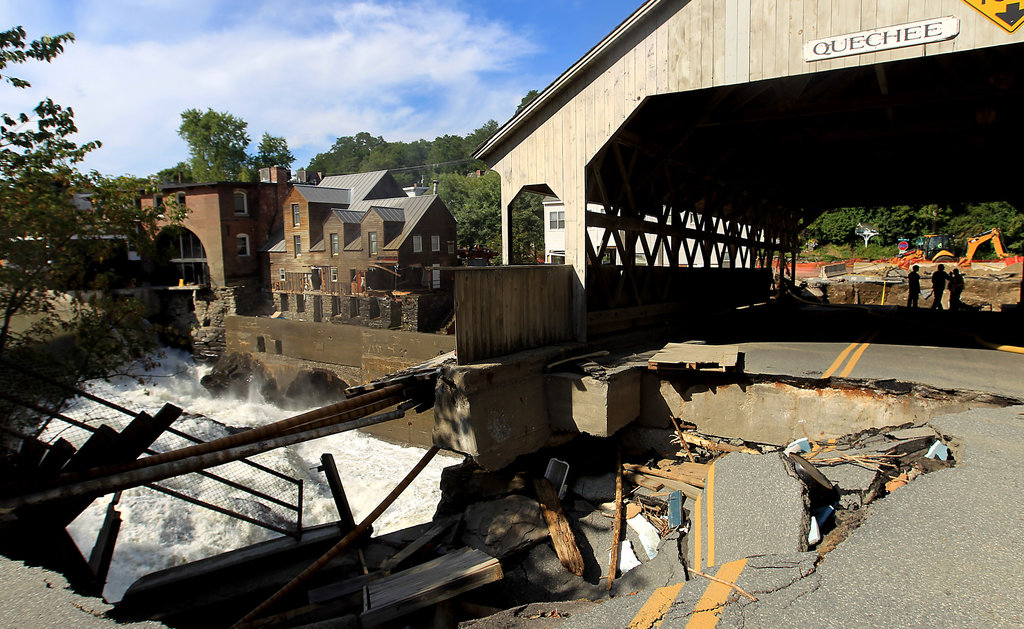

Image loaded: bridge_damage_1532.jpg


In [13]:
from PIL import Image
from IPython.display import display

image_path = list(uploaded_image.keys())[0]

image = Image.open(image_path).convert("RGB")
display(image)

print("Image loaded:", image_path)

In [14]:
sample = next(
    item for item in data
    if item["image_path"].endswith("bridge_damage_1600.jpg")
)

print("Question:", sample["question"])
print("Ground truth:", sample["groundtruth_answer"])
print("Question type:", sample["question_type"])

Question: Is there visible damage to infrastructure in the image? Answer with Yes or No.
Ground truth: Yes
Question type: Binary


In [16]:
from transformers import AutoProcessor

model_id = "HuggingFaceTB/SmolVLM-500M-Instruct"

processor = AutoProcessor.from_pretrained(model_id)

print("Processor loaded successfully!")

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/7.34k [00:00<?, ?B/s]

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.


...

merges.txt:   0%|          | 0.00/466k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/4.74k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.55M [00:00<?, ?B/s]

Processor loaded successfully!


In [19]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText

model_id = "HuggingFaceTB/SmolVLM-500M-Instruct"

print("Loading SmolVLM...")

processor = AutoProcessor.from_pretrained(model_id)

model = AutoModelForImageTextToText.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("SmolVLM loaded successfully!")

Loading SmolVLM...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.02GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

SmolVLM loaded successfully!


In [20]:
question = sample["question"]

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": question}
        ]
    }
]

prompt = processor.apply_chat_template(
    messages,
    add_generation_prompt=True
)

inputs = processor(
    text=prompt,
    images=image,
    return_tensors="pt"
).to(model.device)

with torch.no_grad():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=30
    )

prediction = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

print("Question:", question)
print("Ground truth:", sample["groundtruth_answer"])
print("SmolVLM:", prediction)

Question: Is there visible damage to infrastructure in the image? Answer with Yes or No.
Ground truth: Yes
SmolVLM: User:



Is there visible damage to infrastructure in the image? Answer with Yes or No.
Assistant: Yes.


In [21]:
image_questions = [
    item for item in data
    if item["image_path"].endswith("bridge_damage_1600.jpg")
]

print("Questions for this image:", len(image_questions))

for item in image_questions:
    print("\nQuestion ID:", item["question_id"])
    print("Type:", item["question_type"])
    print("Question:", item["question"])
    print("Ground truth:", item["groundtruth_answer"])

Questions for this image: 4

Question ID: imgq-1
Type: Binary
Question: Is there visible damage to infrastructure in the image? Answer with Yes or No.
Ground truth: Yes

Question ID: imgq-2
Type: Binary
Question: Can vehicles pass through? Answer with Yes or No.
Ground truth: No

Question ID: imgq-3
Type: Multiple-Choice
Question: What type of infrastructure is damaged in the image? Select all that apply.
Ground truth: ['A', 'B']

Question ID: imgq-4
Type: Open-Ended
Question: How many vehicles are visible? Answer with one or two words.
Ground truth: ['One', '1', 'One vehicle', '1 vehicle']


In [22]:
results = []

for item in image_questions:

    question = item["question"]

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": question}
            ]
        }
    ]

    prompt = processor.apply_chat_template(
        messages,
        add_generation_prompt=True
    )

    inputs = processor(
        text=prompt,
        images=image,
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=30
        )

    prediction = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True
    )[0]

    results.append({
        "question_id": item["question_id"],
        "question_type": item["question_type"],
        "question": question,
        "ground_truth": item["groundtruth_answer"],
        "prediction": prediction
    })

    print("\n", item["question_id"])
    print("GT:", item["groundtruth_answer"])
    print("Prediction:", prediction)


 imgq-1
GT: Yes
Prediction: User:



Is there visible damage to infrastructure in the image? Answer with Yes or No.
Assistant: Yes.

 imgq-2
GT: No
Prediction: User:



Can vehicles pass through? Answer with Yes or No.
Assistant: Yes.

 imgq-3
GT: ['A', 'B']
Prediction: User:



What type of infrastructure is damaged in the image? Select all that apply.
Assistant: There is a broken bridge in the image.

 imgq-4
GT: ['One', '1', 'One vehicle', '1 vehicle']
Prediction: User:



How many vehicles are visible? Answer with one or two words.
Assistant: 2.


In [23]:
import pandas as pd

results_df = pd.DataFrame(results)

display(results_df)

,question_id,question_type,question,ground_truth,prediction
0,imgq-1,Binary,Is there visible damage to infrastructure in t...,Yes,User:\n\n\n\nIs there visible damage to infras...
1,imgq-2,Binary,Can vehicles pass through? Answer with Yes or No.,No,User:\n\n\n\nCan vehicles pass through? Answer...
2,imgq-3,Multiple-Choice,What type of infrastructure is damaged in the ...,"[A, B]",User:\n\n\n\nWhat type of infrastructure is da...
3,imgq-4,Open-Ended,How many vehicles are visible? Answer with one...,"[One, 1, One vehicle, 1 vehicle]",User:\n\n\n\nHow many vehicles are visible? An...
